灰度图片+一个卷积核

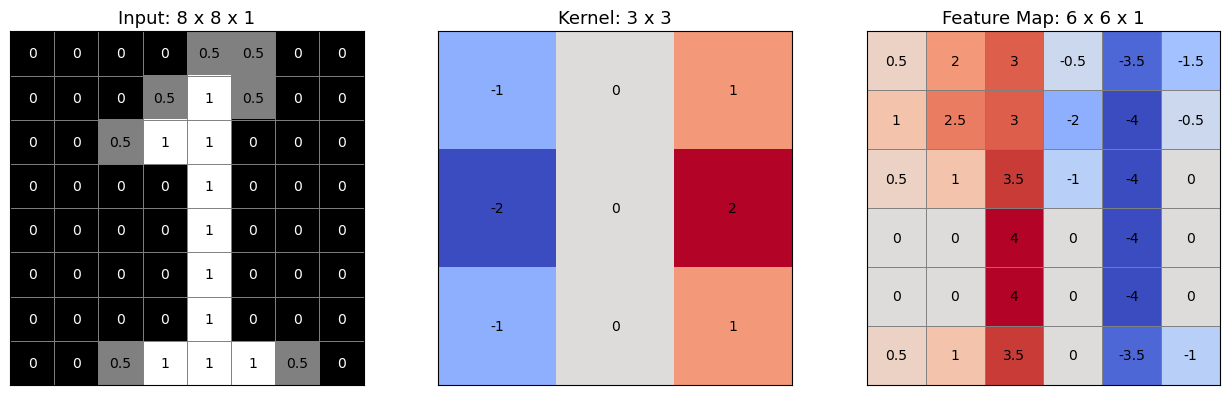

输入尺寸: (1, 1, 8, 8)
卷积核权重尺寸: (1, 1, 3, 3)
输出尺寸: (1, 1, 6, 6)


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [5]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from IPython.display import display, Math

# 1. 构造 8×8 灰度图，表示手写数字 1（0=黑色，1=白色）
image = torch.tensor([
    [0,0,0,0,0.5,0.5,0,0],
    [0,0,0,0.5,1,0.5,0,0],
    [0,0,0.5,1,1,0,0,0],
    [0,0,0,0,1,0,0,0],
    [0,0,0,0,1,0,0,0],
    [0,0,0,0,1,0,0,0],
    [0,0,0,0,1,0,0,0],
    [0,0,0.5,1,1,1,0.5,0]
], dtype=torch.float32)

x = image.unsqueeze(0).unsqueeze(0)

# 2. 定义一个 3×3 卷积核，用于检测垂直边缘
kernel1 = torch.tensor([[-1,0,1],[-2,0,2],[-1,0,1]], dtype=torch.float32)
conv1 = nn.Conv2d(in_channels=1, out_channels=1, kernel_size=3, stride=1, padding=0, bias=False)

with torch.no_grad():
    conv1.weight[0,0].copy_(kernel1)
    y1 = conv1(x)

# 3. 绘制矩阵，显示每个位置的数值
def show_matrix(ax, data, title, gray=False):
    a = data.detach().cpu().numpy()
    vmax = max(1, np.abs(a).max())
    ax.imshow(a, cmap="gray" if gray else "coolwarm", vmin=0 if gray else -vmax, vmax=1 if gray else vmax)

    for i in range(a.shape[0]):
        for j in range(a.shape[1]):
            color = "white" if gray and a[i,j] < 0.5 else "black"
            ax.text(j, i, f"{a[i,j]:g}", ha="center", va="center", fontsize=10, color=color)

    ax.set_xticks(np.arange(-0.5, a.shape[1], 1), minor=True)
    ax.set_yticks(np.arange(-0.5, a.shape[0], 1), minor=True)
    ax.grid(which="minor", color="gray", linewidth=0.7)
    ax.tick_params(which="both", bottom=False, left=False, labelbottom=False, labelleft=False)
    ax.set_title(title, fontsize=13)

# 4. 绘制三个图
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

show_matrix(axes[0], x[0,0], "Input: 8 x 8 x 1", gray=True)
show_matrix(axes[1], kernel1, "Kernel: 3 x 3")
show_matrix(axes[2], y1[0,0], "Feature Map: 6 x 6 x 1")

plt.tight_layout()
plt.show()

# 5. 输出各阶段尺寸
print("输入尺寸:", tuple(x.shape))
print("卷积核权重尺寸:", tuple(conv1.weight.shape))
print("输出尺寸:", tuple(y1.shape))

# 6. 将 PyTorch Tensor 转换为 LaTeX 矩阵
def to_latex_matrix(tensor):
    a = tensor.detach().cpu().numpy()
    rows = [" & ".join(f"{v:g}" for v in row) for row in a]
    return r"\begin{bmatrix}" + r"\\".join(rows) + r"\end{bmatrix}"

# 7. LaTeX 分三行显示输入矩阵、卷积核矩阵和输出矩阵

# 第一行：8×8 输入矩阵
display(Math(r"\text{Input Matrix: } 8\times8"))
display(Math(rf"I={to_latex_matrix(x[0,0])}"))

# 第二行：3×3 卷积核矩阵
display(Math(r"\text{Convolution Kernel: } 3\times3"))
display(Math(rf"K_1={to_latex_matrix(kernel1)}"))

# 第三行：6×6 输出特征图矩阵
display(Math(r"\text{Output Feature Map: } 6\times6"))
display(Math(rf"F_1={to_latex_matrix(y1[0,0])}"))

灰度图+两个卷积核

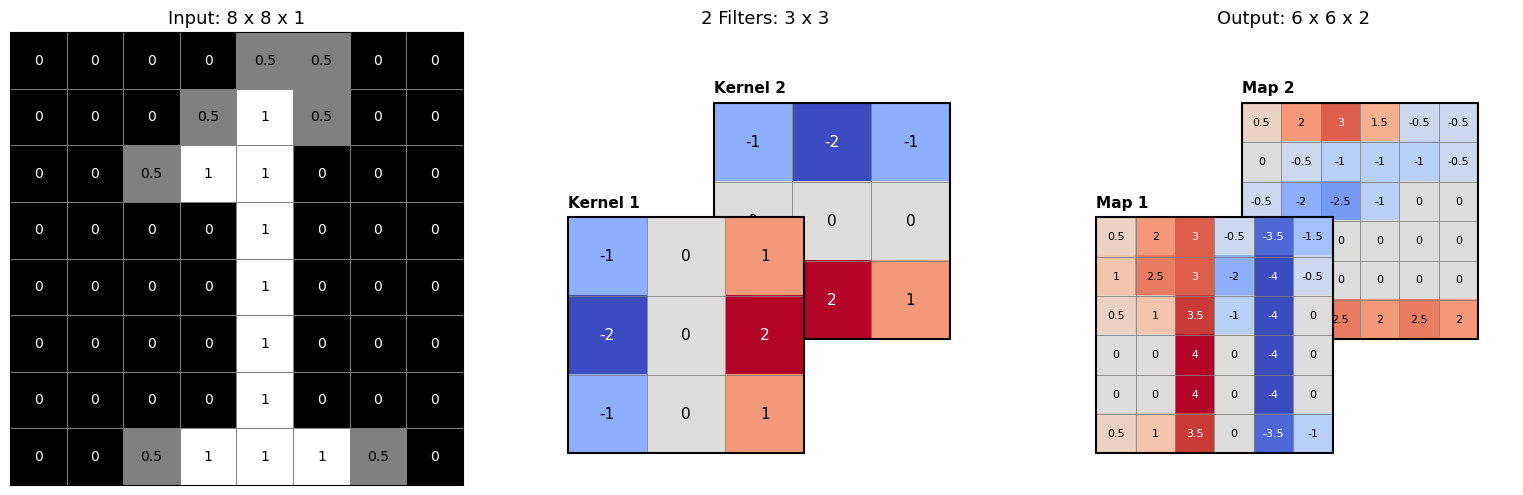

输入尺寸: (1, 1, 8, 8)
卷积核权重尺寸: (2, 1, 3, 3)
输出尺寸: (1, 2, 6, 6)


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [9]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from IPython.display import display, Math

# 1. 构造 8×8 灰度图，表示手写数字 1（0=黑色，1=白色）
image = torch.tensor([
    [0,0,0,0,0.5,0.5,0,0],
    [0,0,0,0.5,1,0.5,0,0],
    [0,0,0.5,1,1,0,0,0],
    [0,0,0,0,1,0,0,0],
    [0,0,0,0,1,0,0,0],
    [0,0,0,0,1,0,0,0],
    [0,0,0,0,1,0,0,0],
    [0,0,0.5,1,1,1,0.5,0]
], dtype=torch.float32)

x = image.unsqueeze(0).unsqueeze(0)  # [1,1,8,8]

# 2. 定义两个 3×3 卷积核
kernel1 = torch.tensor([[-1,0,1],[-2,0,2],[-1,0,1]], dtype=torch.float32)
kernel2 = torch.tensor([[-1,-2,-1],[0,0,0],[1,2,1]], dtype=torch.float32)

# 3. 卷积层：1 个输入通道，2 个 Filter
conv2 = nn.Conv2d(in_channels=1, out_channels=2, kernel_size=3, stride=1, padding=0, bias=False)

with torch.no_grad():
    conv2.weight.copy_(torch.stack([kernel1,kernel2]).unsqueeze(1))
    y2 = conv2(x)

# 4. 绘制矩阵，显示每个位置的数值
def show_matrix(ax, data, title, gray=False):
    a = data.detach().cpu().numpy()
    vmax = max(1,np.abs(a).max())
    ax.imshow(a,cmap="gray" if gray else "coolwarm",
              vmin=0 if gray else -vmax,vmax=1 if gray else vmax)

    for i in range(a.shape[0]):
        for j in range(a.shape[1]):
            color = "white" if gray and a[i,j]<0.5 else "black"
            ax.text(j,i,f"{a[i,j]:g}",ha="center",va="center",fontsize=10,color=color)

    ax.set_xticks(np.arange(-0.5,a.shape[1],1),minor=True)
    ax.set_yticks(np.arange(-0.5,a.shape[0],1),minor=True)
    ax.grid(which="minor",color="gray",linewidth=0.7)
    ax.tick_params(which="both",bottom=False,left=False,labelbottom=False,labelleft=False)
    ax.set_title(title,fontsize=13)

# 5. 绘制带数值的错位堆叠矩阵
def show_stack(ax, matrices, title, labels):
    arrays = [m.detach().cpu().numpy() for m in matrices]
    vmax = max(1,max(np.abs(a).max() for a in arrays))
    cmap = plt.get_cmap("coolwarm")
    size = 0.60
    positions = [(0.06,0.08),(0.43,0.37)]

    for idx in [1,0]:
        a = arrays[idx]
        ox,oy = positions[idx]
        z = 1 if idx==1 else 5
        rows,cols = a.shape

        ax.imshow(a,cmap="coolwarm",vmin=-vmax,vmax=vmax,origin="upper",
                  extent=(ox,ox+size,oy,oy+size),zorder=z)

        for k in range(1,cols):
            xx = ox+k*size/cols
            ax.plot([xx,xx],[oy,oy+size],color="gray",linewidth=0.6,zorder=z+1)

        for k in range(1,rows):
            yy = oy+k*size/rows
            ax.plot([ox,ox+size],[yy,yy],color="gray",linewidth=0.6,zorder=z+1)

        for i in range(rows):
            for j in range(cols):
                value = a[i,j]
                xx = ox+(j+0.5)*size/cols
                yy = oy+size-(i+0.5)*size/rows
                r,g,b,_ = cmap((value+vmax)/(2*vmax))
                color = "white" if 0.2126*r+0.7152*g+0.0722*b<0.48 else "black"
                ax.text(xx,yy,f"{value:g}",ha="center",va="center",
                        fontsize=11 if rows==3 else 8,color=color,zorder=z+2)

        ax.add_patch(plt.Rectangle((ox,oy),size,size,fill=False,
                                   edgecolor="black",linewidth=1.5,zorder=z+3))
        ax.text(ox,oy+size+0.025,labels[idx],fontsize=11,weight="bold",zorder=z+3)

    ax.set_xlim(0,1.12)
    ax.set_ylim(0,1.15)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title,fontsize=13)

# 6. 在同一行绘制三个图
fig, axes = plt.subplots(1,3,figsize=(16,5))

show_matrix(axes[0],x[0,0],"Input: 8 x 8 x 1",gray=True)
show_stack(axes[1],[kernel1,kernel2],"2 Filters: 3 x 3",["Kernel 1","Kernel 2"])
show_stack(axes[2],[y2[0,0],y2[0,1]],"Output: 6 x 6 x 2",["Map 1","Map 2"])

plt.tight_layout()
plt.show()

# 7. 输出各阶段尺寸
print("输入尺寸:",tuple(x.shape))
print("卷积核权重尺寸:",tuple(conv2.weight.shape))
print("输出尺寸:",tuple(y2.shape))

# 8. 将 PyTorch Tensor 转换为 LaTeX 矩阵
def to_latex_matrix(tensor):
    a = tensor.detach().cpu().numpy()
    rows = [" & ".join(f"{v:g}" for v in row) for row in a]
    return r"\begin{bmatrix}" + r"\\".join(rows) + r"\end{bmatrix}"

# 9. 第一行：显示 8×8 输入矩阵
display(Math(r"\text{Input Matrix: } 8\times8"))
display(Math(rf"I={to_latex_matrix(x[0,0])}"))

# 10. 第二行：显示两个 3×3 卷积核（横向排列）
display(Math(r"\text{Convolution Kernels: } 3\times3"))
display(Math(
    rf"K_1={to_latex_matrix(kernel1)}"
    rf"\qquad K_2={to_latex_matrix(kernel2)}"
))

# 11. 第三行：显示两个 6×6 输出特征图（横向排列）
display(Math(r"\text{Output Feature Maps: } 6\times6\times2"))
display(Math(
    rf"F_1={to_latex_matrix(y2[0,0])}"
    rf"\qquad F_2={to_latex_matrix(y2[0,1])}"
))

增加ReLU+最大池化层+Flatten+Linear

最后一列的10个数值，分别是倒数第二列9个数值的加权线性组合(最后一列的 10 个神经元是人为设置的，并不是由前面 9 个神经元决定的)，再加上各自的偏置（Bias），目前的 90 个权重和 10 个 Bias 都是随机初始化的。将来训练 CNN 时，反向传播会优化它们

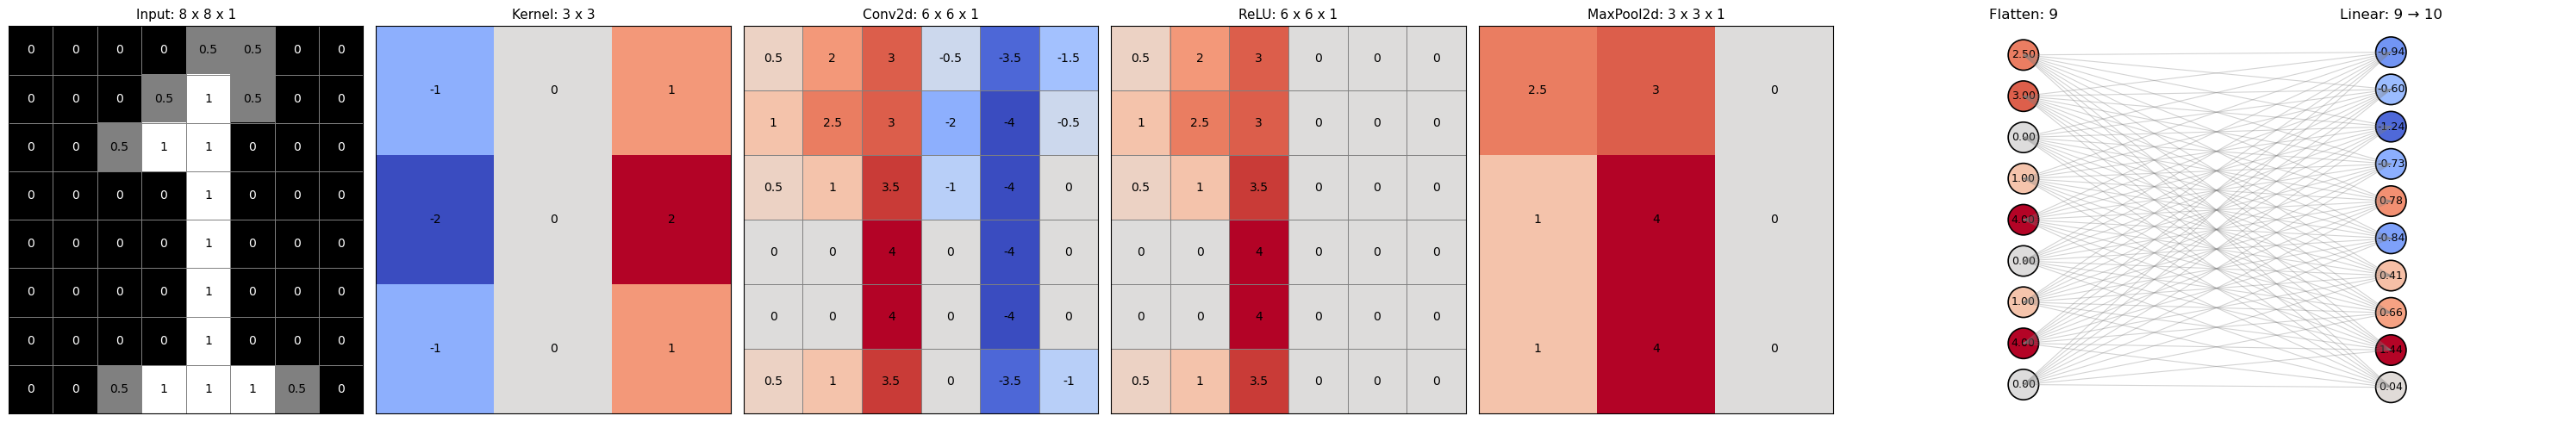

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [10]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from matplotlib.patches import ConnectionPatch
from IPython.display import display, Math

torch.manual_seed(0)

# 1. 构造 8×8 灰度图，表示手写数字 1（0=黑色，1=白色）
image = torch.tensor([
    [0,0,0,0,0.5,0.5,0,0],
    [0,0,0,0.5,1,0.5,0,0],
    [0,0,0.5,1,1,0,0,0],
    [0,0,0,0,1,0,0,0],
    [0,0,0,0,1,0,0,0],
    [0,0,0,0,1,0,0,0],
    [0,0,0,0,1,0,0,0],
    [0,0,0.5,1,1,1,0.5,0]
], dtype=torch.float32)

x = image.unsqueeze(0).unsqueeze(0)

# 2. 定义一个 3×3 卷积核，用于检测垂直边缘
kernel1 = torch.tensor([[-1,0,1],[-2,0,2],[-1,0,1]], dtype=torch.float32)
conv1 = nn.Conv2d(in_channels=1, out_channels=1, kernel_size=3, stride=1, padding=0, bias=False)

# 3. 定义 ReLU、最大池化、Flatten 和 Linear
relu = nn.ReLU()
pool = nn.MaxPool2d(kernel_size=2, stride=2)
flatten = nn.Flatten()
linear = nn.Linear(in_features=9, out_features=10, bias=True) #最后一列的 10 个神经元是人为设置的，并不是由前面 9 个神经元决定的

with torch.no_grad():
    conv1.weight[0,0].copy_(kernel1)
    y1 = conv1(x)
    y_relu = relu(y1)
    y_pool = pool(y_relu)
    y_flat = flatten(y_pool)
    y_linear = linear(y_flat)

# 4. 绘制矩阵，显示每个位置的数值；1D 向量自动画成 1×N
def show_matrix(ax, data, title, gray=False):
    a = data.detach().cpu().numpy()
    if a.ndim == 1:
        a = a.reshape(1, -1)
    vmax = max(1, np.abs(a).max())
    ax.imshow(a, cmap="gray" if gray else "coolwarm", vmin=0 if gray else -vmax, vmax=1 if gray else vmax, aspect="auto")
    for i in range(a.shape[0]):
        for j in range(a.shape[1]):
            color = "white" if gray and a[i,j] < 0.5 else "black"
            fs = 10 if max(a.shape) <= 8 else 9
            ax.text(j, i, f"{a[i,j]:g}", ha="center", va="center", fontsize=fs, color=color)
    ax.set_xticks(np.arange(-0.5, a.shape[1], 1), minor=True)
    ax.set_yticks(np.arange(-0.5, a.shape[0], 1), minor=True)
    ax.grid(which="minor", color="gray", linewidth=0.7)
    ax.tick_params(which="both", bottom=False, left=False, labelbottom=False, labelleft=False)
    ax.set_title(title, fontsize=11)

# 5. 绘制列向量形式的神经元，每个圆圈显示对应数值，并返回圆心坐标
def show_neurons(ax, data, title):
    a = data.detach().cpu().numpy().flatten()
    n = len(a)
    ys = np.arange(n)[::-1]
    vmax = max(1, np.abs(a).max())

    ax.scatter(np.zeros(n), ys, c=a, cmap="coolwarm", vmin=-vmax, vmax=vmax,
               s=650, edgecolors="black", linewidths=1.2, zorder=3)

    for i, value in enumerate(a):
        ax.text(0, ys[i], f"{value:.2f}", ha="center", va="center", fontsize=9, zorder=4)

    ax.set_xlim(-0.8, 0.8)
    ax.set_ylim(-0.7, n-0.3)
    ax.set_aspect("auto")
    ax.axis("off")
    ax.set_title(title, fontsize=12)
    return np.zeros(n), ys

# 6. 在同一行绘制七个图
fig, axes = plt.subplots(1, 7, figsize=(30, 5))

show_matrix(axes[0], x[0,0], "Input: 8 x 8 x 1", gray=True)
show_matrix(axes[1], kernel1, "Kernel: 3 x 3")
show_matrix(axes[2], y1[0,0], "Conv2d: 6 x 6 x 1")
show_matrix(axes[3], y_relu[0,0], "ReLU: 6 x 6 x 1")
show_matrix(axes[4], y_pool[0,0], "MaxPool2d: 3 x 3 x 1")

# Flatten 和 Linear 使用竖直排列的圆圈
x1s, y1s = show_neurons(axes[5], y_flat[0], "Flatten: 9")
x2s, y2s = show_neurons(axes[6], y_linear[0], "Linear: 9 → 10")

# 7. 在最后两个图之间增加全连接线
for y_left in y1s:
    for y_right in y2s:
        con = ConnectionPatch(xyA=(0, y_left), coordsA=axes[5].transData,
                              xyB=(0, y_right), coordsB=axes[6].transData,
                              color="gray", alpha=0.35, linewidth=0.8, zorder=1)
        fig.add_artist(con)

plt.tight_layout()
plt.show()

# 8. 将 PyTorch Tensor 转换为 LaTeX 矩阵；1D 向量自动转成 1×N
def to_latex_matrix(tensor):
    a = tensor.detach().cpu().numpy()
    if a.ndim == 1:
        a = a.reshape(1, -1)
    rows = [" & ".join(f"{v:g}" for v in row) for row in a]
    return r"\begin{bmatrix}" + r"\\".join(rows) + r"\end{bmatrix}"

# 9. LaTeX 显示卷积核矩阵
display(Math(r"\text{Convolution Kernel}"))
display(Math(rf"K_1 = {to_latex_matrix(kernel1)}"))

# 10. LaTeX 显示卷积后的特征图
display(Math(r"\text{Convolution Output}"))
display(Math(rf"F_1 = {to_latex_matrix(y1[0,0])}"))

# 11. LaTeX 显示经过 ReLU 后的特征图
display(Math(r"\text{ReLU Output}"))
display(Math(rf"F_{{\mathrm{{ReLU}}}} = {to_latex_matrix(y_relu[0,0])}"))

# 12. LaTeX 显示经过最大池化后的特征图
display(Math(r"\text{Max Pooling Output}"))
display(Math(rf"F_{{\mathrm{{Pool}}}} = {to_latex_matrix(y_pool[0,0])}"))

# 13. LaTeX 显示 Flatten 后的向量
display(Math(r"\text{Flatten Output}"))
display(Math(rf"F_{{\mathrm{{Flat}}}} = {to_latex_matrix(y_flat[0])}"))

# 14. LaTeX 显示 Linear 输出向量
display(Math(r"\text{Linear Output}"))
display(Math(rf"F_{{\mathrm{{Linear}}}} = {to_latex_matrix(y_linear[0])}"))

两个卷积核

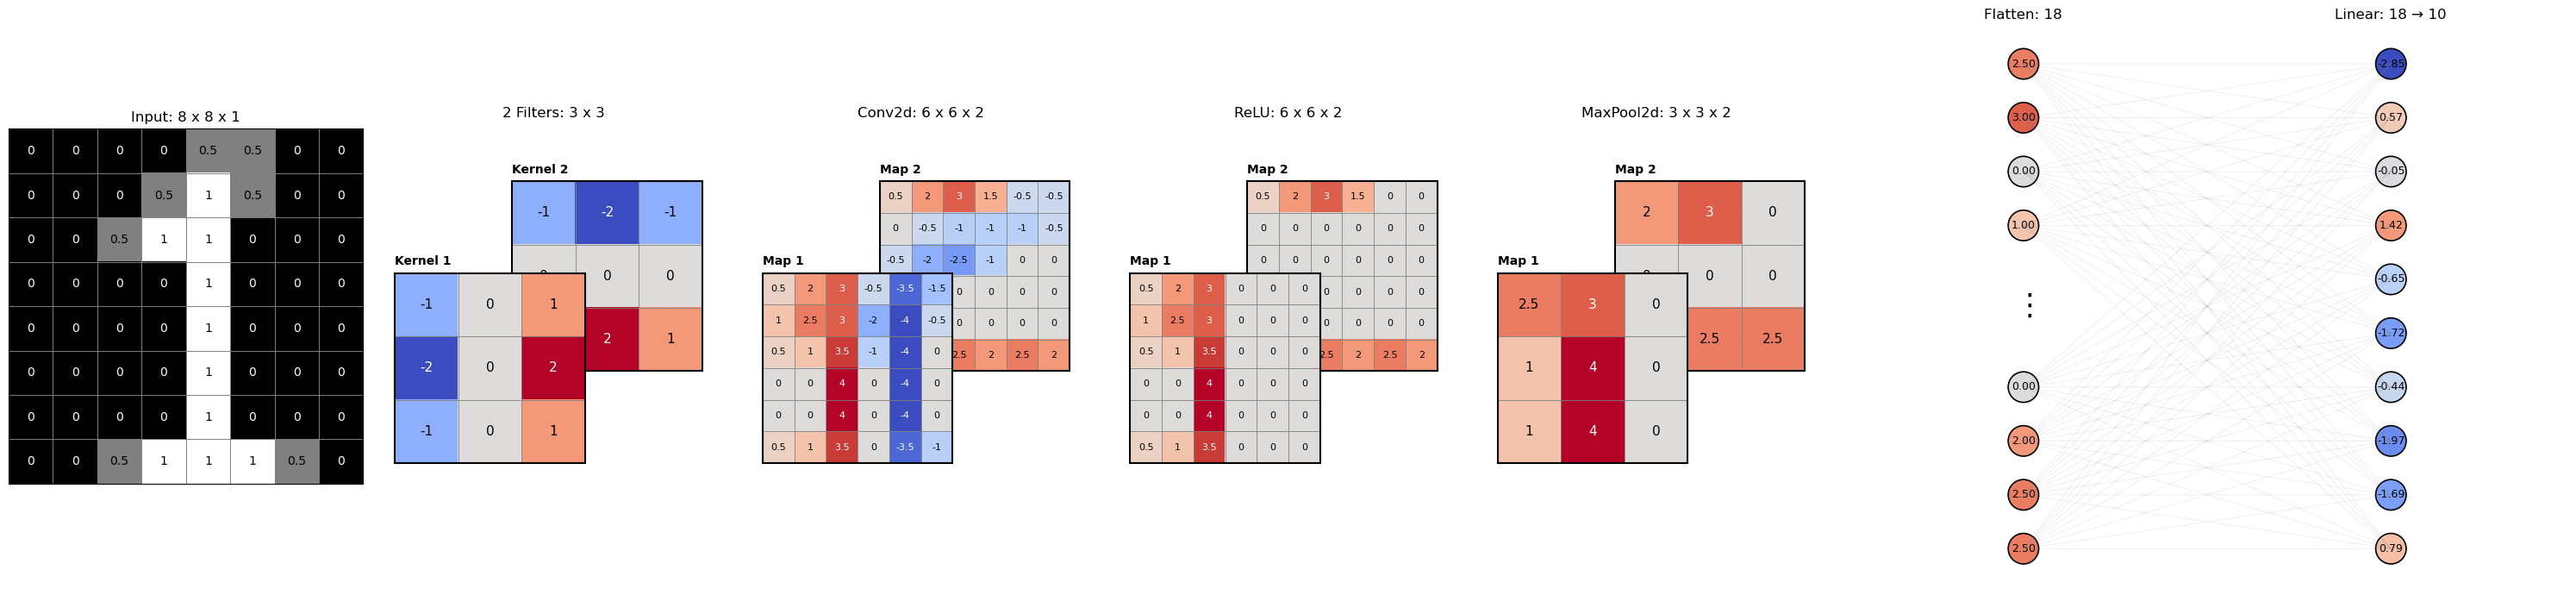

输入尺寸: (1, 1, 8, 8)
卷积核权重尺寸: (2, 1, 3, 3)
卷积输出尺寸: (1, 2, 6, 6)
ReLU 输出尺寸: (1, 2, 6, 6)
最大池化输出尺寸: (1, 2, 3, 3)
Flatten 输出尺寸: (1, 18)
Linear 输出尺寸: (1, 10)


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [11]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from matplotlib.patches import ConnectionPatch
from IPython.display import display, Math

torch.manual_seed(0)

# 1. 定义两个 3×3 卷积核，分别检测垂直和水平边缘
kernel1 = torch.tensor([[-1,0,1],[-2,0,2],[-1,0,1]], dtype=torch.float32)
kernel2 = torch.tensor([[-1,-2,-1],[0,0,0],[1,2,1]], dtype=torch.float32)

# 2. 定义卷积层：1 个输入通道，2 个 Filter
conv2 = nn.Conv2d(in_channels=1, out_channels=2, kernel_size=3, stride=1, padding=0, bias=False)

# 3. 定义 ReLU、最大池化、Flatten 和 Linear
relu2 = nn.ReLU()
pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
flatten2 = nn.Flatten()
linear2 = nn.Linear(in_features=18, out_features=10, bias=True)

with torch.no_grad():
    conv2.weight.copy_(torch.stack([kernel1, kernel2]).unsqueeze(1))
    y2 = conv2(x)
    y_relu2 = relu2(y2)
    y_pool2 = pool2(y_relu2)
    y_flat2 = flatten2(y_pool2)
    y_linear2 = linear2(y_flat2)

# 4. 绘制单通道矩阵，显示每个像素的数值
def show_matrix(ax, data, title, gray=False):
    a = data.detach().cpu().numpy()
    vmax = max(1, np.abs(a).max())
    ax.imshow(a, cmap="gray" if gray else "coolwarm", vmin=0 if gray else -vmax, vmax=1 if gray else vmax)

    for i in range(a.shape[0]):
        for j in range(a.shape[1]):
            color = "white" if gray and a[i,j] < 0.5 else "black"
            ax.text(j,i,f"{a[i,j]:g}",ha="center",va="center",fontsize=10,color=color)

    ax.set_xticks(np.arange(-0.5,a.shape[1],1),minor=True)
    ax.set_yticks(np.arange(-0.5,a.shape[0],1),minor=True)
    ax.grid(which="minor",color="gray",linewidth=0.7)
    ax.tick_params(which="both",bottom=False,left=False,labelbottom=False,labelleft=False)
    ax.set_title(title,fontsize=12)

# 5. 绘制两个通道的错位堆叠矩阵，每层显示数值
def show_stack(ax, matrices, title, labels):
    arrays = [m.detach().cpu().numpy() for m in matrices]
    vmax = max(1, max(np.abs(a).max() for a in arrays))
    cmap = plt.get_cmap("coolwarm")
    size = 0.60
    positions = [(0.06,0.08),(0.43,0.37)]

    for idx in [1,0]:
        a = arrays[idx]
        ox, oy = positions[idx]
        z = 1 if idx == 1 else 5
        rows, cols = a.shape

        ax.imshow(a,cmap="coolwarm",vmin=-vmax,vmax=vmax,origin="upper",
                  extent=(ox,ox+size,oy,oy+size),zorder=z)

        for k in range(1,cols):
            xx = ox + k*size/cols
            ax.plot([xx,xx],[oy,oy+size],color="gray",linewidth=0.6,zorder=z+1)

        for k in range(1,rows):
            yy = oy + k*size/rows
            ax.plot([ox,ox+size],[yy,yy],color="gray",linewidth=0.6,zorder=z+1)

        for i in range(rows):
            for j in range(cols):
                value = a[i,j]
                xx = ox + (j+0.5)*size/cols
                yy = oy + size - (i+0.5)*size/rows
                r,g,b,_ = cmap((value+vmax)/(2*vmax))
                color = "white" if 0.2126*r+0.7152*g+0.0722*b < 0.48 else "black"
                ax.text(xx,yy,f"{value:g}",ha="center",va="center",
                        fontsize=11 if rows==3 else 8,color=color,zorder=z+2)

        ax.add_patch(plt.Rectangle((ox,oy),size,size,fill=False,
                                  edgecolor="black",linewidth=1.5,zorder=z+3))
        ax.text(ox,oy+size+0.025,labels[idx],fontsize=10,weight="bold",zorder=z+3)

    ax.set_xlim(0,1.12)
    ax.set_ylim(0,1.15)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title,fontsize=12)

# 6. 绘制神经元，超过 12 个时省略中间部分
def show_neurons(ax, data, title):
    a = data.detach().cpu().numpy().flatten()
    n = len(a)
    vmax = max(1, np.abs(a).max())

    if n > 12:
        indices = list(range(4)) + list(range(n-4,n))
        ys = np.array([9,8,7,6,3,2,1,0])
        ax.text(0,4.5,r"$\vdots$",ha="center",va="center",fontsize=25)
    else:
        indices = list(range(n))
        ys = np.arange(n)[::-1]

    values = a[indices]
    ax.scatter(np.zeros(len(indices)),ys,c=values,cmap="coolwarm",
               vmin=-vmax,vmax=vmax,s=650,edgecolors="black",linewidths=1.2,zorder=3)

    for i,value in enumerate(values):
        ax.text(0,ys[i],f"{value:.2f}",ha="center",va="center",fontsize=9,zorder=4)

    ax.set_xlim(-0.8,0.8)
    ax.set_ylim(-0.7,max(9,n-1 if n<=12 else 9)+0.7)
    ax.set_aspect("auto")
    ax.axis("off")
    ax.set_title(title,fontsize=12)
    return np.zeros(len(indices)),ys

# 7. 在同一行绘制七个图
fig, axes = plt.subplots(1,7,figsize=(30,7))

show_matrix(axes[0],x[0,0],"Input: 8 x 8 x 1",gray=True)
show_stack(axes[1],[kernel1,kernel2],"2 Filters: 3 x 3",["Kernel 1","Kernel 2"])
show_stack(axes[2],[y2[0,0],y2[0,1]],"Conv2d: 6 x 6 x 2",["Map 1","Map 2"])
show_stack(axes[3],[y_relu2[0,0],y_relu2[0,1]],"ReLU: 6 x 6 x 2",["Map 1","Map 2"])
show_stack(axes[4],[y_pool2[0,0],y_pool2[0,1]],"MaxPool2d: 3 x 3 x 2",["Map 1","Map 2"])

# Flatten 和 Linear 使用竖直排列的圆圈
x1s, y1s = show_neurons(axes[5],y_flat2[0],"Flatten: 18")
x2s, y2s = show_neurons(axes[6],y_linear2[0],"Linear: 18 → 10")

# 8. 在 Flatten 和 Linear 之间绘制全连接线，共 18×10=180 条
for y_left in y1s:
    for y_right in y2s:
        con = ConnectionPatch(xyA=(0,y_left),coordsA=axes[5].transData,
                              xyB=(0,y_right),coordsB=axes[6].transData,
                              color="gray",alpha=0.15,linewidth=0.6,zorder=1)
        fig.add_artist(con)

plt.tight_layout()
plt.show()

# 9. 输出各阶段尺寸
print("输入尺寸:",tuple(x.shape))
print("卷积核权重尺寸:",tuple(conv2.weight.shape))
print("卷积输出尺寸:",tuple(y2.shape))
print("ReLU 输出尺寸:",tuple(y_relu2.shape))
print("最大池化输出尺寸:",tuple(y_pool2.shape))
print("Flatten 输出尺寸:",tuple(y_flat2.shape))
print("Linear 输出尺寸:",tuple(y_linear2.shape))

# 10. 将 PyTorch Tensor 转换为 LaTeX 矩阵
def to_latex_matrix(tensor):
    a = tensor.detach().cpu().numpy()
    if a.ndim == 1:
        a = a.reshape(1,-1)
    rows = [" & ".join(f"{v:.4g}" for v in row) for row in a]
    return r"\begin{bmatrix}" + r"\\".join(rows) + r"\end{bmatrix}"

# 11. LaTeX 显示两个卷积核
display(Math(r"\text{Convolution Kernels}"))
display(Math(rf"K_1={to_latex_matrix(kernel1)} \qquad K_2={to_latex_matrix(kernel2)}"))

# 12. LaTeX 显示两个卷积输出矩阵
display(Math(r"\text{Convolution Output}"))
display(Math(rf"F_1={to_latex_matrix(y2[0,0])} \qquad F_2={to_latex_matrix(y2[0,1])}"))

# 13. LaTeX 显示两个 ReLU 输出矩阵
display(Math(r"\text{ReLU Output}"))
display(Math(rf"F_{{\mathrm{{ReLU}},1}}={to_latex_matrix(y_relu2[0,0])} \qquad F_{{\mathrm{{ReLU}},2}}={to_latex_matrix(y_relu2[0,1])}"))

# 14. LaTeX 显示两个最大池化输出矩阵
display(Math(r"\text{Max Pooling Output}"))
display(Math(rf"F_{{\mathrm{{Pool}},1}}={to_latex_matrix(y_pool2[0,0])} \qquad F_{{\mathrm{{Pool}},2}}={to_latex_matrix(y_pool2[0,1])}"))

# 15. LaTeX 显示 Flatten 输出的 18 维向量
display(Math(r"\text{Flatten Output}"))
display(Math(rf"F_{{\mathrm{{Flat}}}}={to_latex_matrix(y_flat2[0])}"))

# 16. LaTeX 显示 Linear 输出的 10 维向量
display(Math(r"\text{Linear Output}"))
display(Math(rf"F_{{\mathrm{{Linear}}}}={to_latex_matrix(y_linear2[0])}"))